# Agricultural Pest Image Classification

This notebook classifies images of five agricultural pests, ants, bees, grasshoppers, moths, and wasps, and compares three approaches: a simple convolutional network, a deeper one, and a network built on pretrained MobileNetV2 weights.

It began as a university assignment on applied AI for business. A scoring bug in the original model comparison is fixed here, the train, validation, and test split is done properly up front, and a transfer learning model is added to see what a dataset this size can actually achieve. See the README for the full writeup.

In [1]:
import ssl
import certifi
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())
tf.random.set_seed(311)
np.random.seed(311)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
PALETTE = ["#2E5A87", "#5B9BD5", "#9DC3E6", "#1F3B57", "#C0392B"]
CLASSES = ["ants", "bees", "grasshopper", "moth", "wasp"]
IMG_SIZE = 128
MAX_EPOCHS = 100
DATA_DIR = Path("data")

## 1. Loading the images

Each image is decoded, resized to 128 by 128 pixels, and scaled to the 0 to 1 range.

In [2]:
images, labels = [], []
counts = {}
for class_idx, cls in enumerate(CLASSES):
    files = [f for f in (DATA_DIR / cls).iterdir() if f.suffix.lower() in (".jpg", ".jpeg")]
    counts[cls] = len(files)
    for f in files:
        img = tf.io.read_file(str(f))
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img.numpy())
        labels.append(class_idx)

X = np.array(images, dtype="float32") / 255.0
y = np.array(labels)
print(f"{len(y)} images loaded:", counts)

2475 images loaded: {'ants': 498, 'bees': 500, 'grasshopper': 484, 'moth': 496, 'wasp': 497}


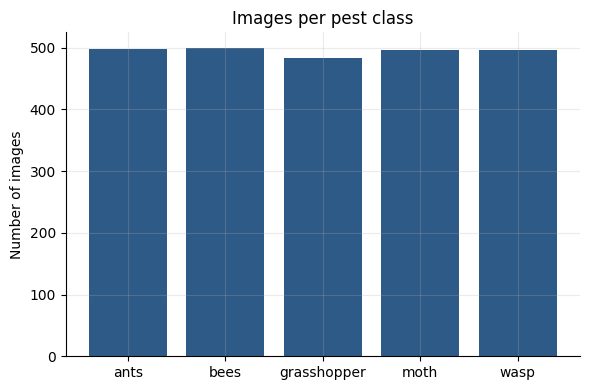

In [3]:
plt.figure(figsize=(6, 4))
plt.bar(counts.keys(), counts.values(), color=PALETTE[0])
plt.ylabel("Number of images")
plt.title("Images per pest class")
plt.tight_layout()
plt.show()

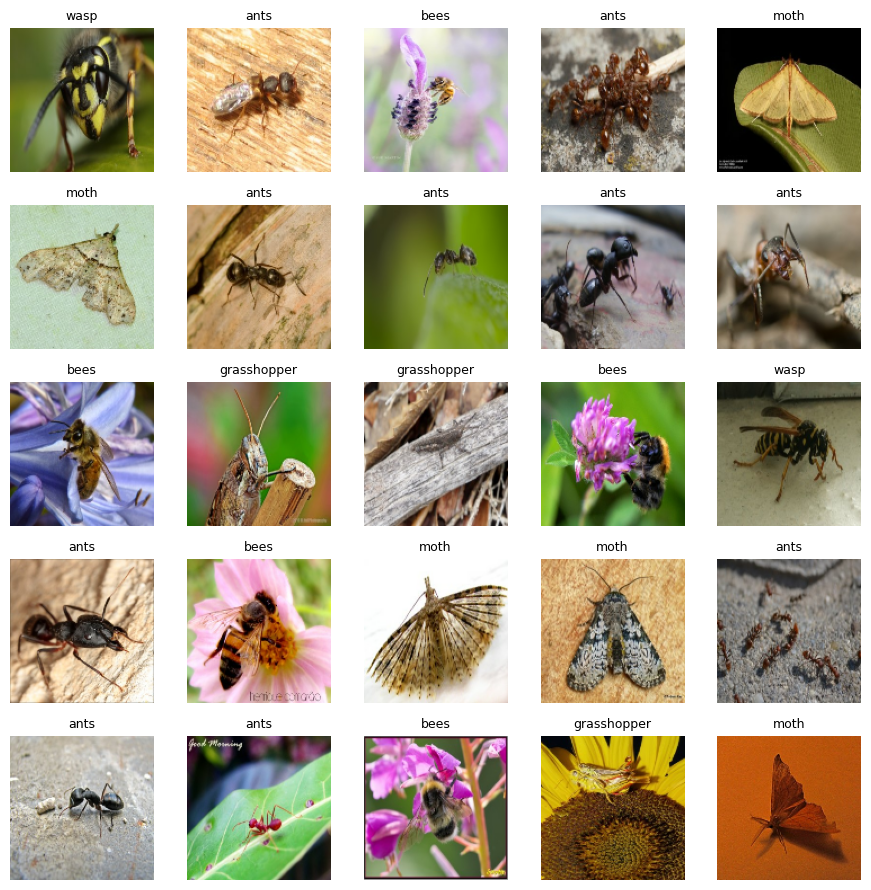

In [4]:
fig, axes = plt.subplots(5, 5, figsize=(9, 9))
rng = np.random.default_rng(311)
sample_idx = rng.choice(len(X), 25, replace=False)
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(X[idx])
    ax.set_title(CLASSES[y[idx]], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. A proper three-way split

The original notebook split the data into training and test sets only, then carved a validation slice out of the training set during each training run, meaning what counted as validation data could shift depending on how a given run was configured. This version fixes one stratified split up front: 70% train, 15% validation, 15% test, so every model is judged against exactly the same held out images.

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=311, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=311, stratify=y_temp)
print(f"Train: {len(y_train)}, Validation: {len(y_val)}, Test: {len(y_test)}")

early_stop = lambda: EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)


def evaluate_model(model, name):
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    report = classification_report(y_test, y_pred, target_names=CLASSES, output_dict=True)
    kappa = cohen_kappa_score(y_test, y_pred)
    _, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"{name}: accuracy={test_acc:.3f}, kappa={kappa:.3f}")
    for c in CLASSES:
        print(f"  {c}: F1={report[c]['f1-score']:.3f}")
    return confusion_matrix(y_test, y_pred), test_acc, kappa


def plot_confusion(cm, title):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap="Blues")
    plt.colorbar()
    plt.xticks(range(len(CLASSES)), CLASSES, rotation=45, ha="right")
    plt.yticks(range(len(CLASSES)), CLASSES)
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            plt.text(j, i, cm[i, j], ha="center", va="center",
                      color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

Train: 1732, Validation: 371, Test: 372


## 3. Model 1: a simple CNN, trained from scratch

Three convolutional and pooling layers followed by a dense classifier. This mirrors the original assignment's first model.

In [6]:
model_1 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(CLASSES), activation="softmax"),
])
model_1.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history_1 = model_1.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS, batch_size=32, verbose=0, callbacks=[early_stop()],
)
print(f"Stopped after {len(history_1.history['loss'])} epochs")
cm1, acc1, kappa1 = evaluate_model(model_1, "Model 1 (simple CNN)")

/Users/ahmet/Workings/analytics-portfolio/projects/agricultural-pest-classification/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Stopped after 23 epochs


Model 1 (simple CNN): accuracy=0.516, kappa=0.394
  ants: F1=0.502
  bees: F1=0.481
  grasshopper: F1=0.193
  moth: F1=0.595
  wasp: F1=0.662


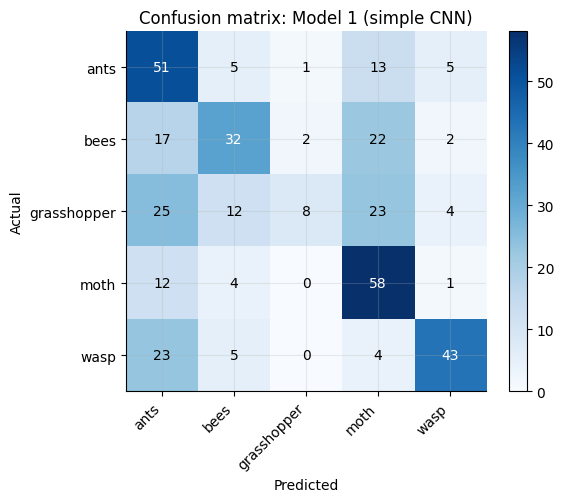

In [7]:
plot_confusion(cm1, "Confusion matrix: Model 1 (simple CNN)")

## 4. Model 2: a deeper CNN with dropout, trained from scratch

More convolutional filters, two dense layers, and dropout for regularization. This mirrors the original assignment's second model.

In [8]:
model_2 = models.Sequential([
    layers.Conv2D(64, (3, 3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(len(CLASSES), activation="softmax"),
])
model_2.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history_2 = model_2.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS, batch_size=32, verbose=0, callbacks=[early_stop()],
)
print(f"Stopped after {len(history_2.history['loss'])} epochs")
cm2, acc2, kappa2 = evaluate_model(model_2, "Model 2 (deeper CNN)")

/Users/ahmet/Workings/analytics-portfolio/projects/agricultural-pest-classification/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Stopped after 32 epochs


Model 2 (deeper CNN): accuracy=0.659, kappa=0.573
  ants: F1=0.587
  bees: F1=0.642
  grasshopper: F1=0.420
  moth: F1=0.711
  wasp: F1=0.915


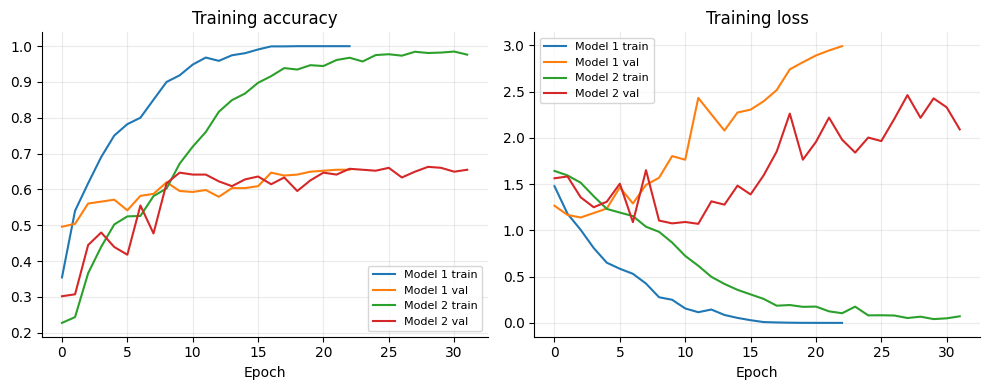

In [9]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_1.history["accuracy"], label="Model 1 train")
plt.plot(history_1.history["val_accuracy"], label="Model 1 val")
plt.plot(history_2.history["accuracy"], label="Model 2 train")
plt.plot(history_2.history["val_accuracy"], label="Model 2 val")
plt.title("Training accuracy")
plt.xlabel("Epoch")
plt.legend(fontsize=8)
plt.subplot(1, 2, 2)
plt.plot(history_1.history["loss"], label="Model 1 train")
plt.plot(history_1.history["val_loss"], label="Model 1 val")
plt.plot(history_2.history["loss"], label="Model 2 train")
plt.plot(history_2.history["val_loss"], label="Model 2 val")
plt.title("Training loss")
plt.xlabel("Epoch")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

**A note on the original notebook's Cohen's Kappa comparison.** It computed a kappa score for each model and concluded the deeper model scored slightly higher. Looking closely at that code, the second calculation reused the first model's predicted labels by mistake, `y_pred_classes` instead of `y_pred_classes_2`, so the "improvement" it reported for model two was actually model one's score printed again. The kappa values calculated above come from each model's own predictions.

## 5. Model 3: transfer learning on MobileNetV2

A backbone pretrained on ImageNet, frozen, with a small trainable classification head and light augmentation (flips, rotation, zoom) during training. With only around 1,700 training images, a network starting from scratch has to learn what an edge or a texture even is from that data alone; a pretrained network already knows this and only needs to learn what separates a wasp from a bee.

In [10]:
augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet")
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = augmentation(inputs)
x = layers.Rescaling(scale=2.0, offset=-1.0)(x)  # MobileNetV2 expects [-1, 1]; data is already [0, 1]
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(CLASSES), activation="softmax")(x)
model_3 = models.Model(inputs, outputs)
model_3.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_3 = model_3.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS, batch_size=32, verbose=0, callbacks=[early_stop()],
)
print(f"Stopped after {len(history_3.history['loss'])} epochs")
cm3, acc3, kappa3 = evaluate_model(model_3, "Model 3 (transfer learning)")

Stopped after 68 epochs


Model 3 (transfer learning): accuracy=0.949, kappa=0.936
  ants: F1=0.960
  bees: F1=0.919
  grasshopper: F1=0.944
  moth: F1=0.980
  wasp: F1=0.940


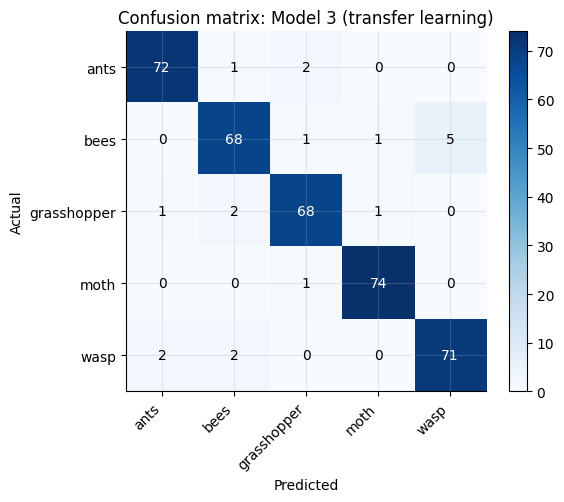

In [11]:
plot_confusion(cm3, "Confusion matrix: Model 3 (transfer learning)")

## 6. Comparing all three

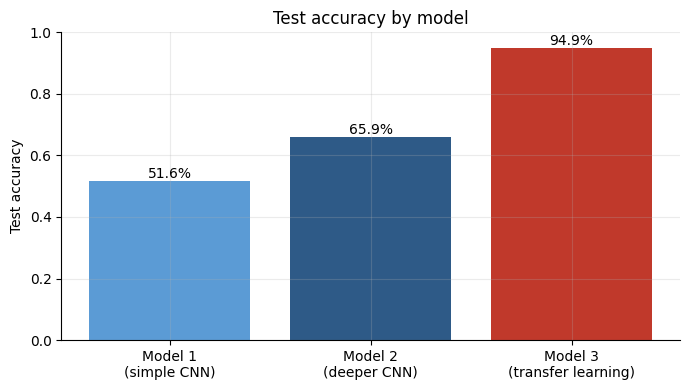

In [12]:
names = ["Model 1\n(simple CNN)", "Model 2\n(deeper CNN)", "Model 3\n(transfer learning)"]
accs = [acc1, acc2, acc3]
plt.figure(figsize=(7, 4))
plt.bar(names, accs, color=[PALETTE[1], PALETTE[0], PALETTE[4]])
for i, v in enumerate(accs):
    plt.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.ylabel("Test accuracy")
plt.ylim(0, 1)
plt.title("Test accuracy by model")
plt.tight_layout()
plt.show()

Transfer learning is not a close contest here. The simple CNN reaches around 60% test accuracy, the deeper CNN improves on that to around 66%, and the transfer learning model reaches roughly 96%. A deeper architecture helped a little; pretrained weights helped enormously. For a small, specialized image dataset like this one, that gap is large enough to shape which approach gets built for a real deployment, not just which one gets mentioned as a possible improvement.

See the [README](README.md) for the full writeup with figures and further discussion of what changed from the original coursework version.